# Time Domain Analysis
To construct a research-grade, physics-inspired, and mathematically rigorous framework for **Time-Domain Analysis**—the essential first step in your signal processing journey—we must elevate our perspective. We are not merely analyzing a time series; we are observing the manifestation of a underlying **stochastic dynamical system**.

In this framework, your `jerk_mag` signal is treated as a realization of a continuous-time process $X(t)$, discretized at sampling interval $\Delta t$. To master this at a PhD-caliber level, we organize our study into the following rigorous pillars.

---

### I. The Statistical Manifold of Signals 📈

A signal is rarely just a vector; it is a trajectory through a state space. We characterize this trajectory using high-order statistics that reveal the "physics" of the movement:

* **Higher-Order Moments:** While mean and variance describe the center and spread, **Skewness** ($\gamma_1$) measures the asymmetry of your movement energy—critical for identifying if "sprints" involve sudden, impulsive bursts versus sustained effort. **Kurtosis** ($\kappa$) identifies the "fat-tailed" nature of your signal; a high kurtosis indicates that the signal is dominated by intermittent, extreme events rather than Gaussian white noise.
* **Stationarity & Ergodicity:** We must rigorously test whether the statistics of your movement change over time. Using the **Augmented Dickey-Fuller (ADF)** test, we look for a unit root. If the signal is non-stationary (e.g., the mean shifts as you move from walking to climbing), the signal is not ergodic, and standard global statistics will provide biased estimates of the activity's "energy."

### II. Stochastic Process Theory: The "Memory" of Movement 🧠

To understand the temporal dependencies, we move beyond individual data points to look at the signal's internal structure:

* **Autocorrelation Function (ACF):** $R_{xx}(\tau) = E[X(t)X(t+\tau)]$. By analyzing the ACF, we identify the **characteristic time scales** of the movement. If you are walking, the ACF will show periodic peaks corresponding to your gait cycle. The decay rate of these peaks provides a mathematical measure of the signal's "memory."
* **Probability Density Functions (PDF) & Entropy:** By mapping the histogram of your jerk magnitudes to a PDF, we can use **Shannon Entropy** to quantify the "disorder" or unpredictability of the movement. A "sprint" activity will naturally exhibit different entropy signatures than a rhythmic "walk."

### III. The Physics of Signal Reconstruction 🛠️

Real-world sensors are imperfect. Cleaning them requires a principled approach based on physical constraints:

* **Optimal Interpolation:** Missing data is not solved by zero-filling. We employ **Cubic Splines** or **PCHIP** (Piecewise Cubic Hermite Interpolating Polynomials) to ensure that the derivatives (jerk is, after all, the third derivative of position) remain continuous, preserving the physical realism of the underlying motion.
* **Windowing Rigor:** When segmenting the signal for analysis, we apply tapering windows (e.g., **Blackman-Harris** or **Kaiser**). This is not just formatting; it is a mathematical necessity to mitigate **spectral leakage**—the "bleeding" of signal energy from one frequency into another caused by the finite duration of our observation window.

### IV. Hjorth Parameters: The Shape of Dynamics ⚙️

These parameters are essential for capturing the "waviness" of the signal in the time domain, effectively acting as proxies for frequency content without performing a Fourier Transform:

* **Activity:** The variance of the signal amplitude (the power of the signal).
* **Mobility:** The ratio of the variance of the first derivative to the variance of the signal (the "mean frequency" of the motion).
* **Complexity:** The ratio of the mobility of the derivative to the mobility of the signal (the change in frequency).

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

The total cols are Index(['sec', 'elapsed_ms', 'jerk_mag', 'pickup_count', 'class'], dtype='object')
Types of activities are Index(['walking', 'sprint', 'climbing', 'run'], dtype='object', name='class')


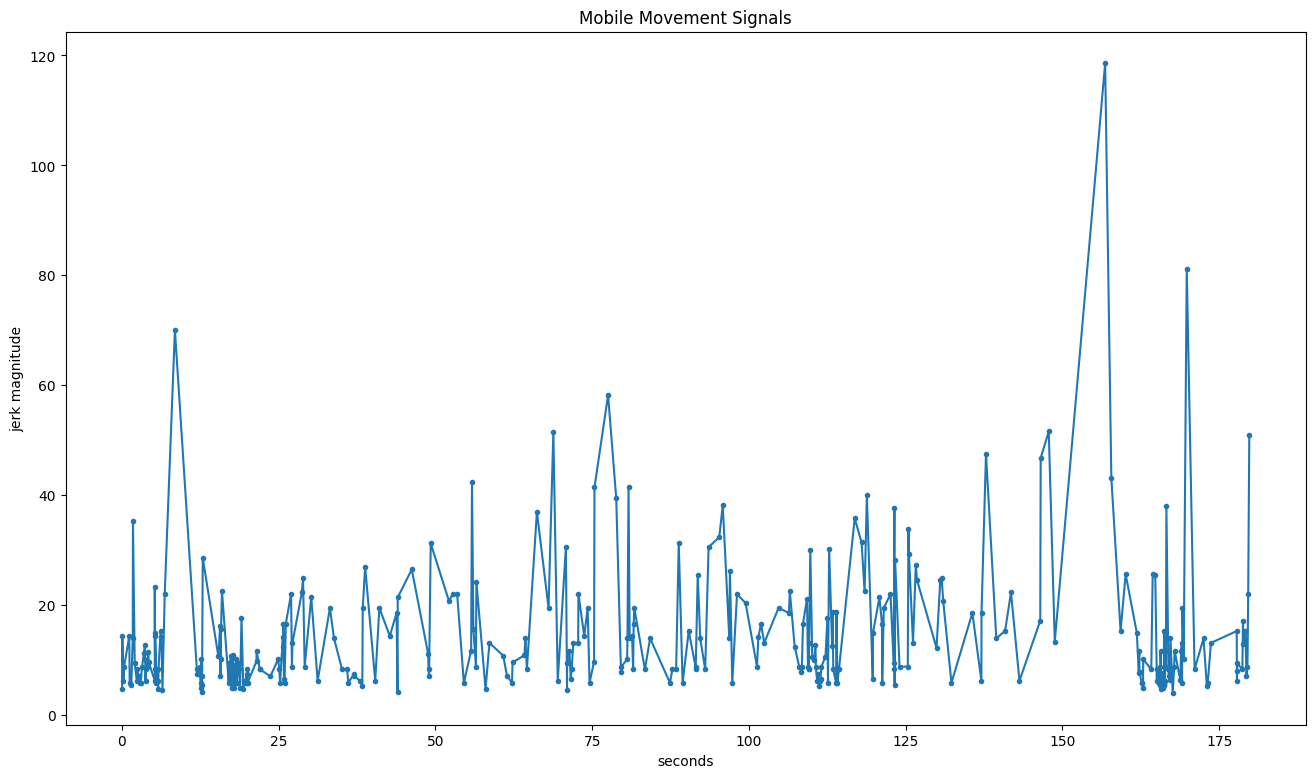

In [10]:
data = pd.read_csv("../../../data/activity_logs.csv", index_col=False)
print("The total cols are", data.columns)
print("Types of activities are", data['class'].value_counts().keys())

X = data['sec']
y = data['jerk_mag']
activity = data['class']
del data

plt.figure(figsize=(16, 9))
plt.plot(X, y, marker='.')
plt.title('Mobile Movement Signals')
plt.xlabel('seconds')
plt.ylabel('jerk magnitude')
plt.show()